# Computer Vision Project
### Bowling Score Detection

In [1]:
!pip install roboflow ultralytics opencv-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/CV Project (Bowling Detection)'
DATASET_DIR = '/content/drive/MyDrive/CV Project (Bowling Detection)/bowling_dataset_yolov8'
VIDEO_PATH = '/content/drive/MyDrive/CV Project (Bowling Detection)/CV_Project_Video.mov'

Mounted at /content/drive


## Dataset Preparation

### Extracting all Frames

In [3]:
import os
import cv2

def extract_all_frames(video_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"Total frames: {total_frames}")
    print(f"FPS: {fps}")
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(f"{output_dir}/frame_{frame_count:05d}.jpg", frame,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        frame_count += 1
        if frame_count % 100 == 0:
            print(f"  {frame_count}/{total_frames} ({frame_count/total_frames*100:.1f}%)")
    cap.release()
    print("Total frames extracted: ", frame_count)
    return frame_count

all_frames_dir = f"{PROJECT_DIR}/all_frames"
extract_all_frames(VIDEO_PATH, all_frames_dir)

Total frames: 900
FPS: 30.0
  100/900 (11.1%)
  200/900 (22.2%)
  300/900 (33.3%)
  400/900 (44.4%)
  500/900 (55.6%)
  600/900 (66.7%)
  700/900 (77.8%)
  800/900 (88.9%)
  900/900 (100.0%)
Total frames extracted:  900


900

### Selecting the Keyfames from the Video

In [5]:
output_folder = f"{PROJECT_DIR}/selected_frames"
os.makedirs(output_folder, exist_ok=True)

ranges = [(65,140), (200,270), (390,400),(440,520), (600,650), (680,730), (800,870)]
selected_frames = set()
for start, end in ranges:
    selected_frames.update(range(start, end + 1))

cap = cv2.VideoCapture(VIDEO_PATH)
frame_id, saved_count = 0, 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_id in selected_frames:
        cv2.imwrite(f"{output_folder}/frame_{frame_id:04d}.jpg", frame)
        saved_count += 1
    frame_id += 1
cap.release()
print("Total Keyframes Selected: ", saved_count)

Total Keyframes Selected:  412


## Downloading the Labelled Dataset from Roboflow

In [6]:
import os
from roboflow import Roboflow

ROBOFLOW_API_KEY = "RZ2gGEfqfePIFvcRWgea"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("malaks-workspace-c8zfr").project("cv_project_2classes")

dataset = project.version(1).download("yolov8", location=DATASET_DIR)
for split in ['train', 'valid']:
    img_dir = f'{DATASET_DIR}/{split}/images'
    lbl_dir = f'{DATASET_DIR}/{split}/labels'
    n_img = len([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
    n_lbl = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
    print(f"{split.upper()}: {n_img} images, {n_lbl} labels")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/drive/MyDrive/CV Project (Bowling Detection)/bowling_dataset_yolov8 in yolov8:: 100%|██████████| 828/828 [00:08<00:00, 98.66it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TRAIN: 330 images, 330 labels
VALID: 82 images, 82 labels


## Model (YOLOv8)

### Training the Model

In [7]:
import torch
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
data_yaml = f'{DATASET_DIR}/data.yaml'

results = model.train(data=data_yaml, epochs=60, imgsz=640, batch=16,
                      name='bowling_v2', patience=15,
                      optimizer='AdamW',lr0=0.01,
                      degrees=0, translate=0.1, scale=0.5,
                      flipud=0.0, fliplr=0.5,
                      plots=True, verbose=True,
                      save=True, save_period=10)

print("Best weights: runs/detect/bowling_v2/weights/best.pt")

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CV Project (Bowling Detection)/bowling_dataset_yolov8/data.yaml, degrees=0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bowling_v2, nbs=64, nms=False, opset=None, opti

## Training Curves and Confusion Matrix

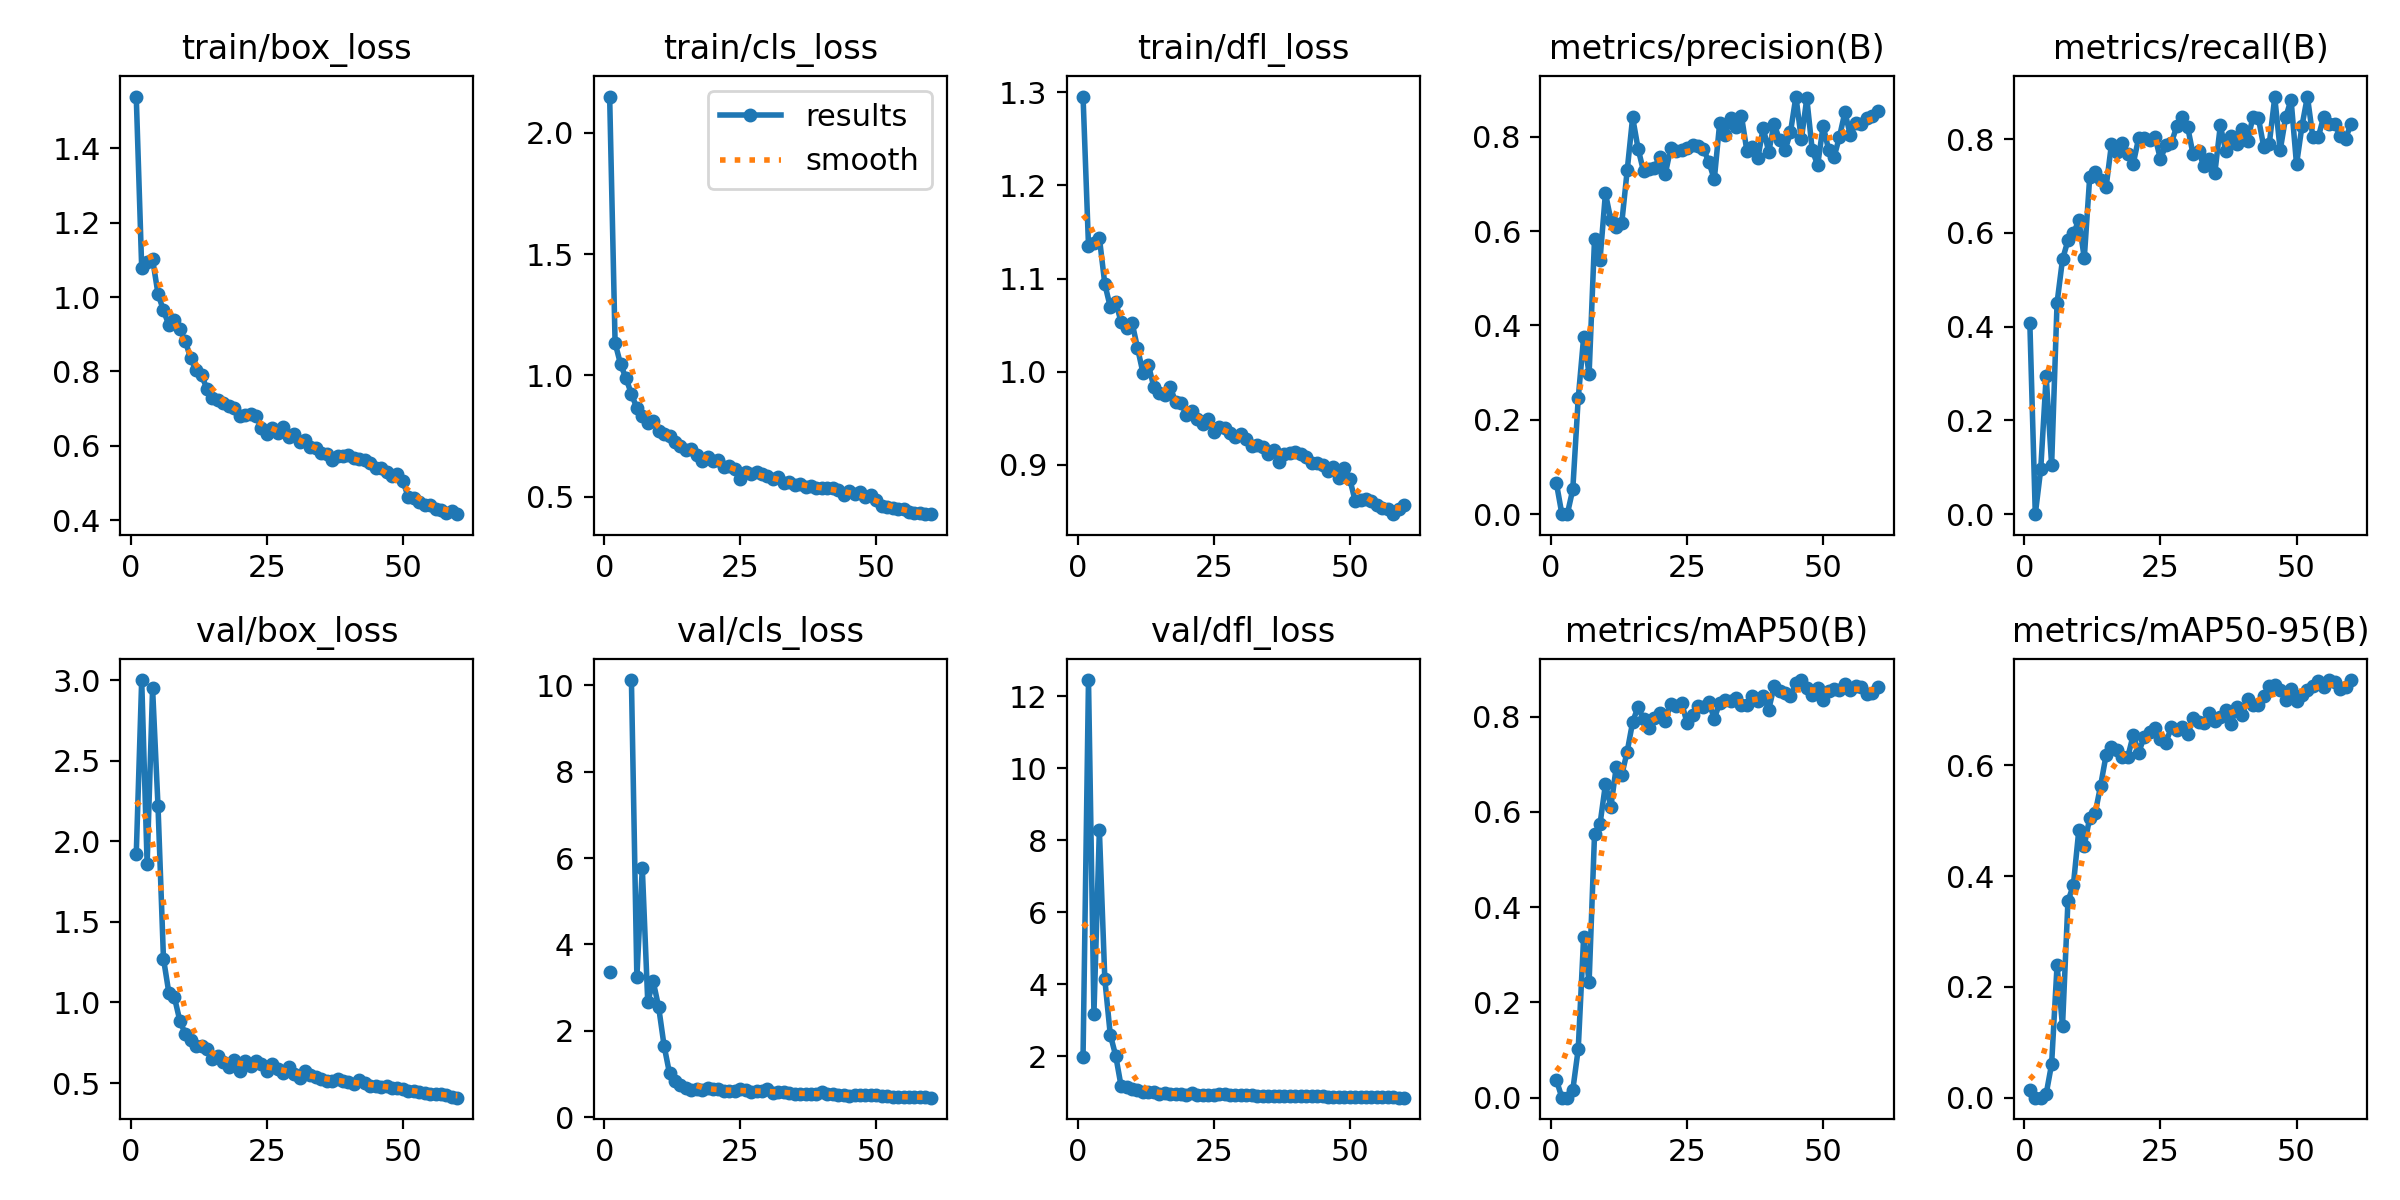

In [8]:
from IPython.display import Image, display
display(Image('runs/detect/bowling_v2/results.png'))

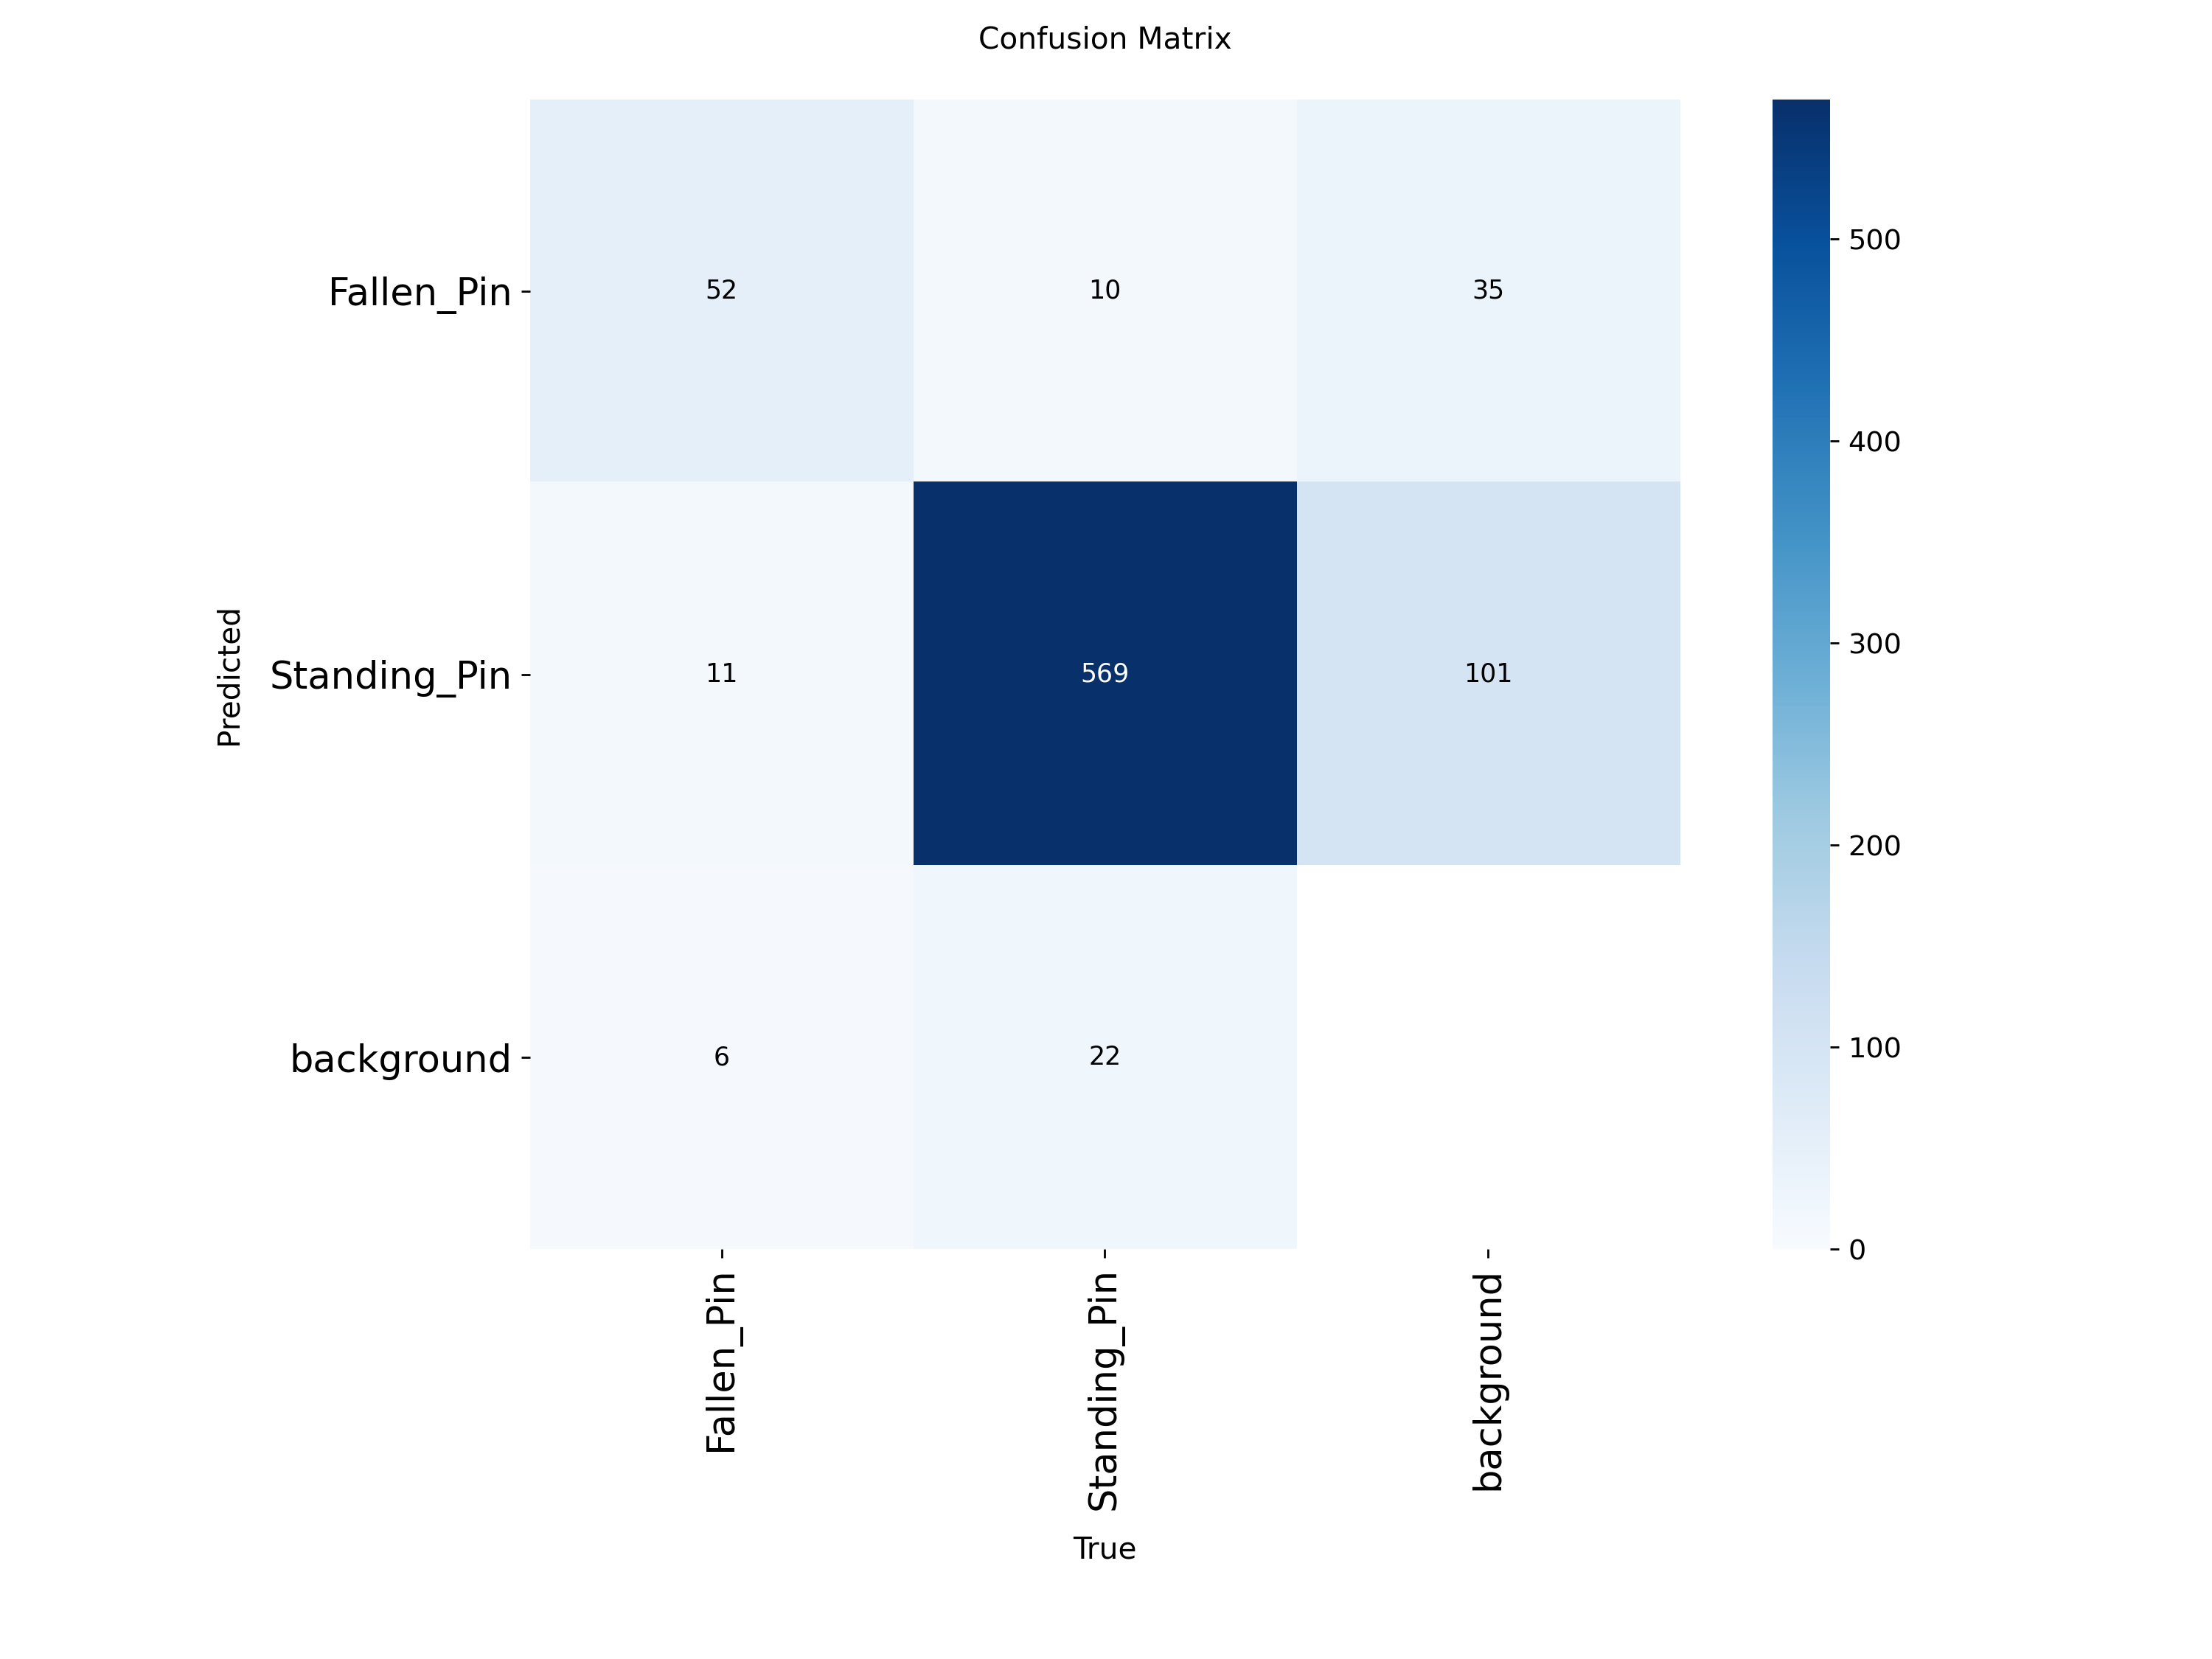

In [10]:
display(Image('runs/detect/bowling_v2/confusion_matrix.png'))

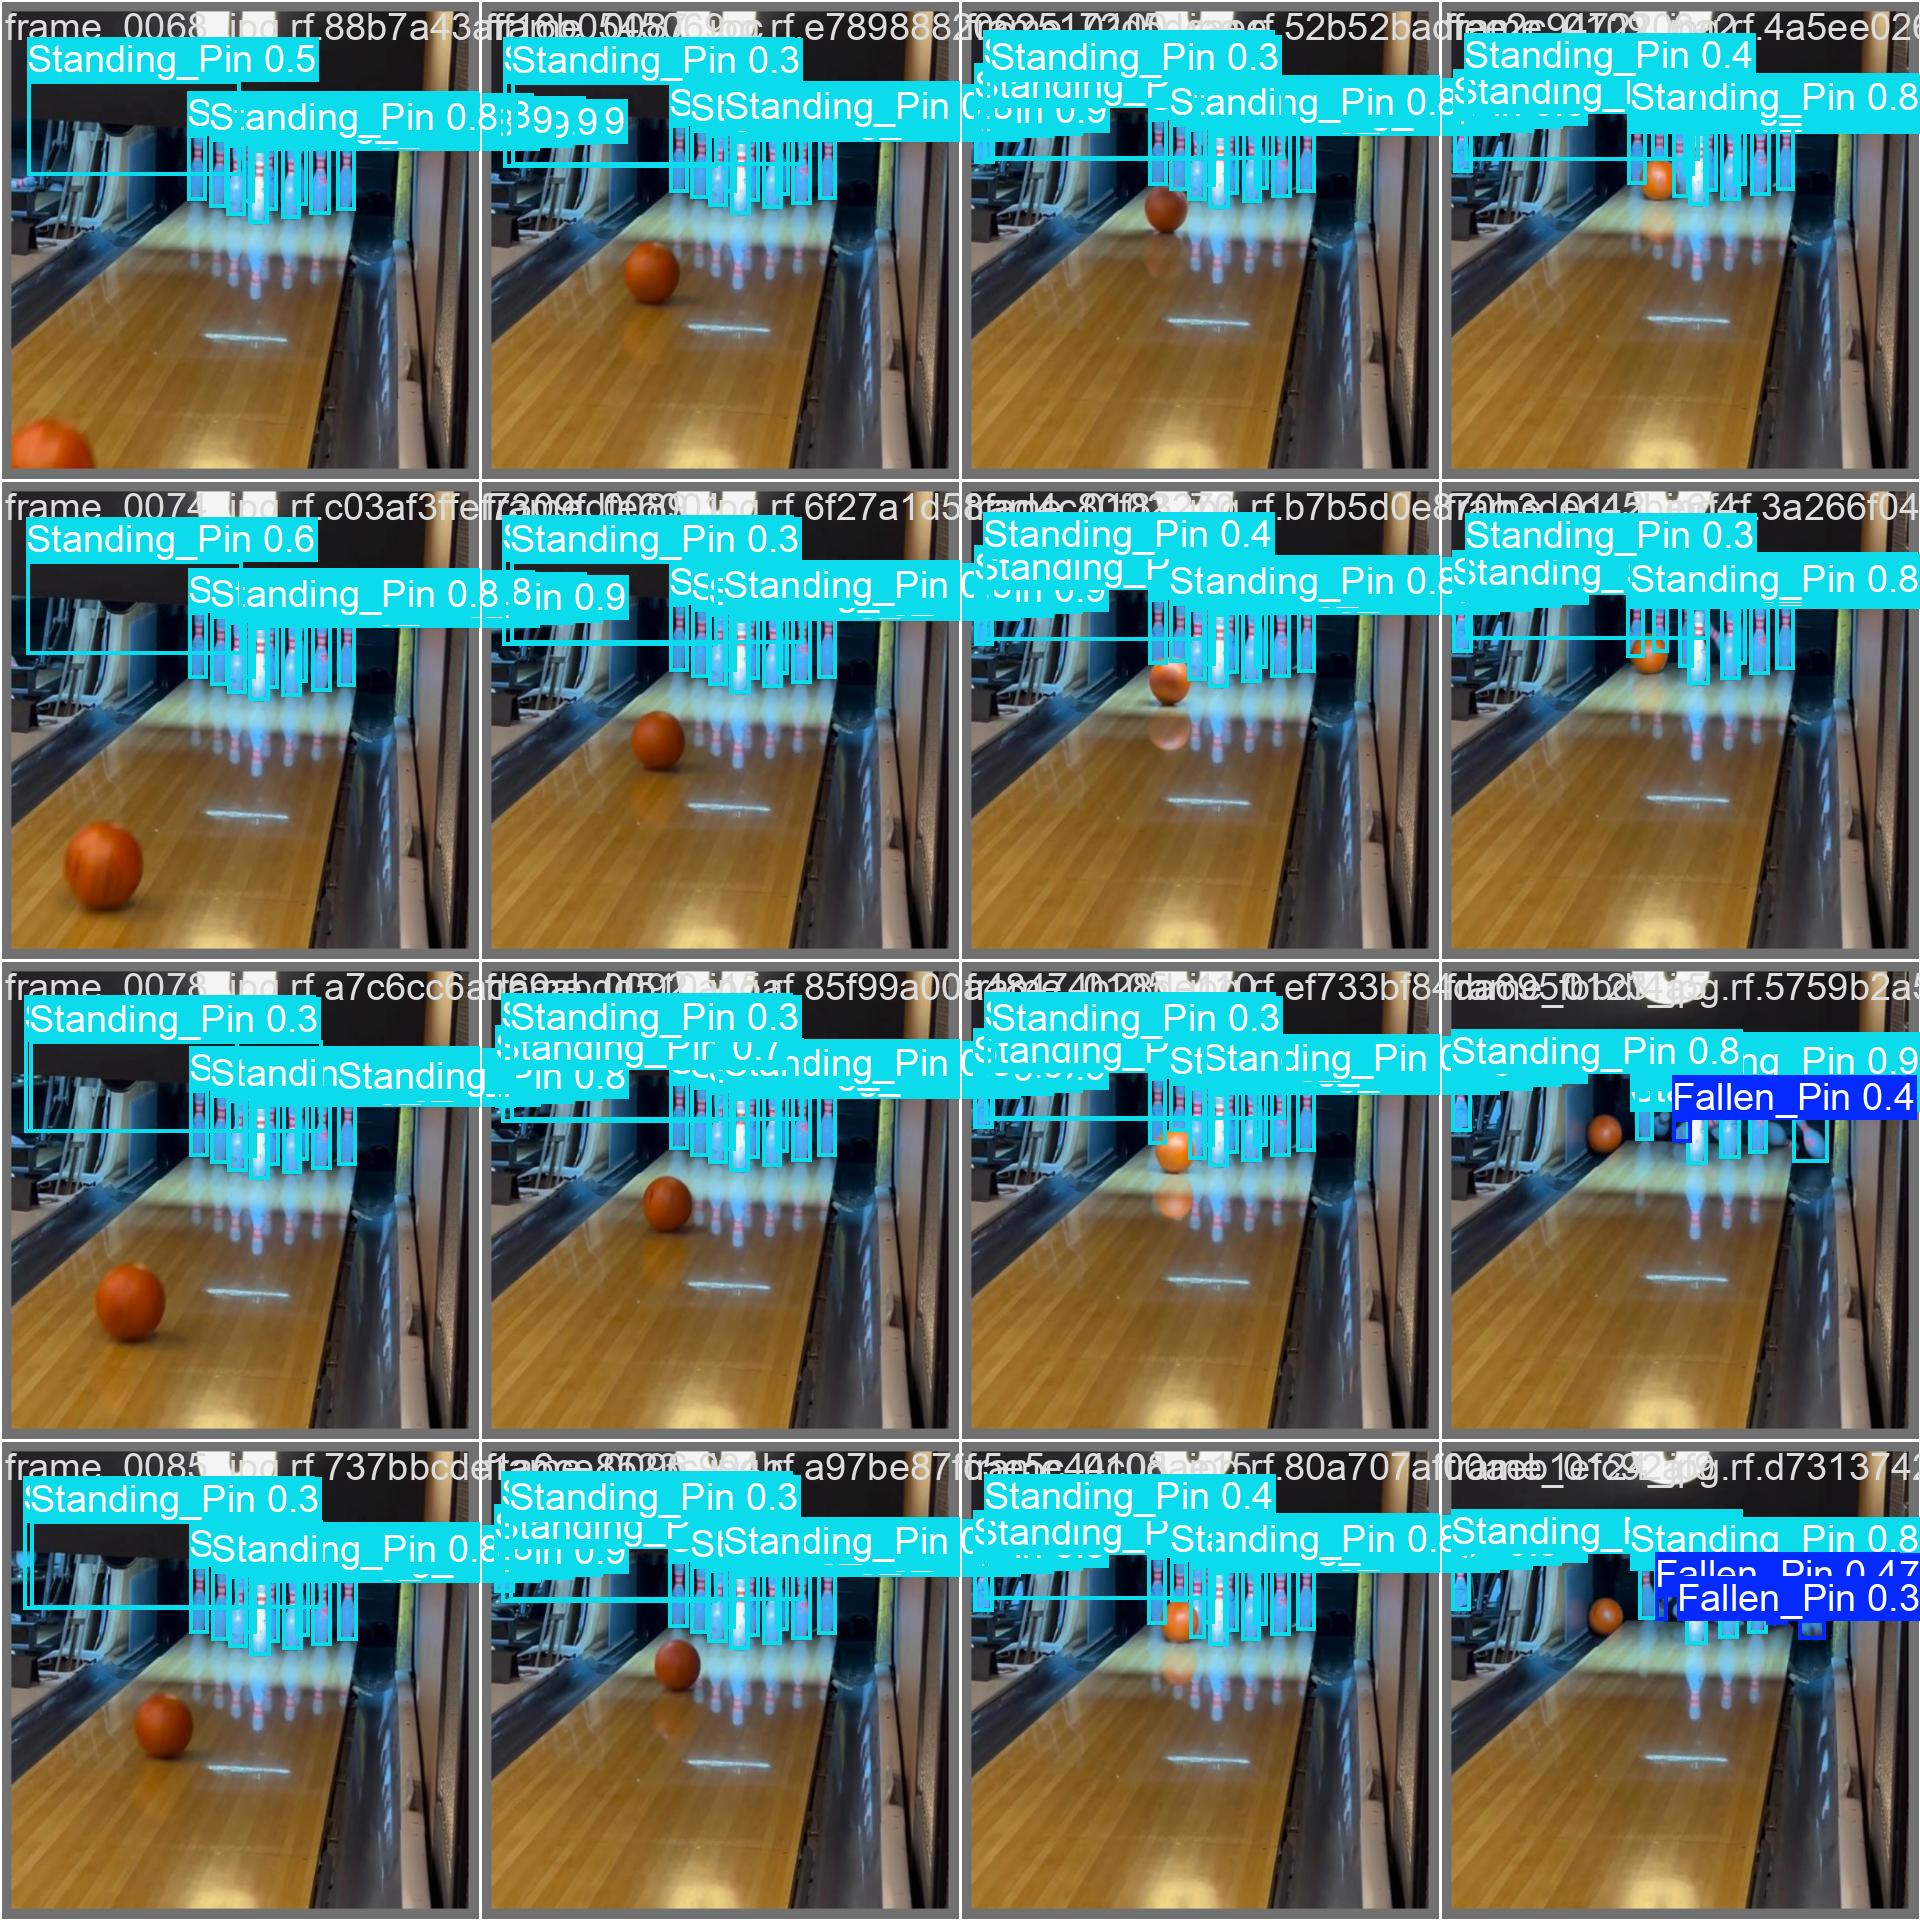

In [11]:
display(Image('runs/detect/bowling_v2/val_batch0_pred.jpg'))

## Evaluation Metrics

In [12]:
from ultralytics import YOLO

best_model = YOLO('runs/detect/bowling_v2/weights/best.pt')
metrics = best_model.val()

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.7 ms, read: 14.0±5.4 MB/s, size: 26.0 KB)
val: Scanning /content/drive/MyDrive/CV Project (Bowling Detection)/bowling_dataset_yolov8/valid/labels.cache... 82 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 21.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.3it/s 4.6s
                   all         82        670      0.854      0.832      0.862      0.757
            Fallen_Pin         26         69      0.811      0.746      0.803       0.66
          Standing_Pin         81        601      0.896      0.918       0.92      0.854
Speed: 5.2ms preprocess, 6.4ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to /content/runs/detect/val


In [13]:
print("MODEL PERFORMANCE")
print(f"mAP@0.5: {metrics.box.map50}")
print(f"mAP@0.5:0.95: {metrics.box.map}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")

MODEL PERFORMANCE
mAP@0.5: 0.8615690846879938
mAP@0.5:0.95: 0.7572608194096284
Precision: 0.8535202832596003
Recall: 0.8321048751868103


## Validating on Validation Samples

In [14]:
import cv2
from google.colab.patches import cv2_imshow

val_images = f'{DATASET_DIR}/valid/images'
test_images = sorted(os.listdir(val_images))[:3]


image 1/1 /content/drive/MyDrive/CV Project (Bowling Detection)/bowling_dataset_yolov8/valid/images/frame_0068_jpg.rf.88b7a43aff16b0545069cc77b273da7d.jpg: 640x640 1 Fallen_Pin, 11 Standing_Pins, 7.3ms
Speed: 3.5ms preprocess, 7.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Testing: frame_0068_jpg.rf.88b7a43aff16b0545069cc77b273da7d.jpg


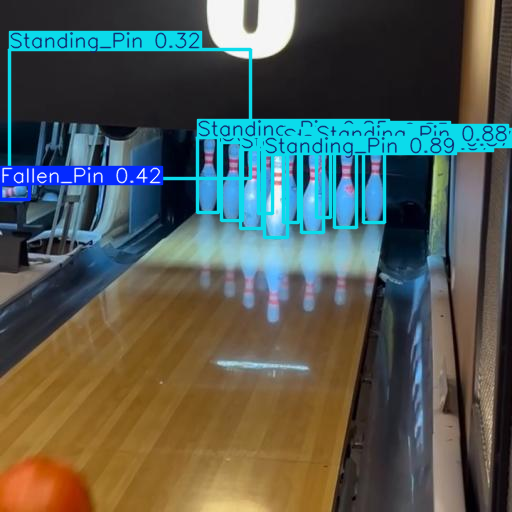

Fallen_Pin: 0.8910263180732727
Fallen_Pin: 0.8761518597602844
Fallen_Pin: 0.8697437644004822
Fallen_Pin: 0.8692868947982788
Fallen_Pin: 0.8686017990112305
Fallen_Pin: 0.8653458952903748
Fallen_Pin: 0.8497986197471619
Fallen_Pin: 0.8455443978309631
Fallen_Pin: 0.8414044380187988
Fallen_Pin: 0.8310779929161072
Standing_Pin: 0.4197376072406769
Fallen_Pin: 0.3241969347000122

image 1/1 /content/drive/MyDrive/CV Project (Bowling Detection)/bowling_dataset_yolov8/valid/images/frame_0074_jpg.rf.c03af3ffef7309fdfe600148b4c76390.jpg: 640x640 11 Standing_Pins, 8.6ms
Speed: 3.8ms preprocess, 8.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Testing: frame_0074_jpg.rf.c03af3ffef7309fdfe600148b4c76390.jpg


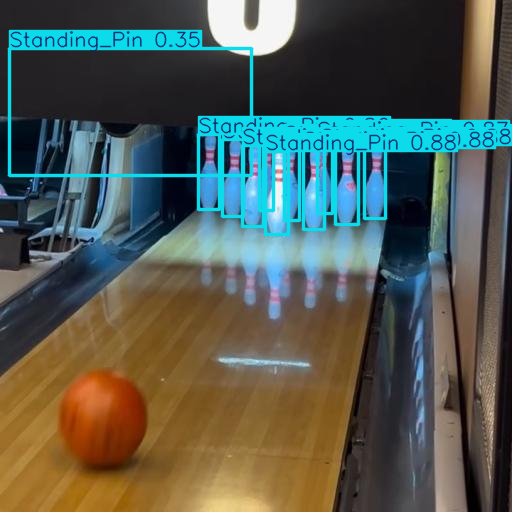

Fallen_Pin: 0.8780336380004883
Fallen_Pin: 0.8779423832893372
Fallen_Pin: 0.8766041994094849
Fallen_Pin: 0.8693175911903381
Fallen_Pin: 0.8625777363777161
Fallen_Pin: 0.8588236570358276
Fallen_Pin: 0.8575880527496338
Fallen_Pin: 0.8554611802101135
Fallen_Pin: 0.8475531935691833
Fallen_Pin: 0.8424669504165649
Fallen_Pin: 0.35012468695640564

image 1/1 /content/drive/MyDrive/CV Project (Bowling Detection)/bowling_dataset_yolov8/valid/images/frame_0078_jpg.rf.a7c6cc6ad69abdd510a15a6ae49f825a.jpg: 640x640 11 Standing_Pins, 8.5ms
Speed: 4.0ms preprocess, 8.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Testing: frame_0078_jpg.rf.a7c6cc6ad69abdd510a15a6ae49f825a.jpg


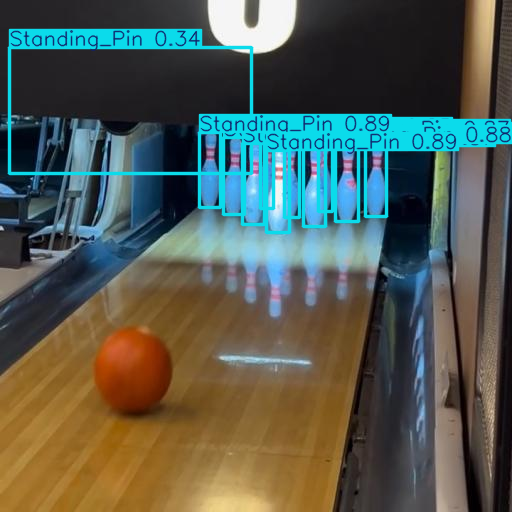

Fallen_Pin: 0.8912976980209351
Fallen_Pin: 0.8867040872573853
Fallen_Pin: 0.8820777535438538
Fallen_Pin: 0.8708879947662354
Fallen_Pin: 0.869450032711029
Fallen_Pin: 0.8680239915847778
Fallen_Pin: 0.8630657196044922
Fallen_Pin: 0.8473652005195618
Fallen_Pin: 0.8461101055145264
Fallen_Pin: 0.8460184335708618
Fallen_Pin: 0.34477031230926514


In [15]:
for img_name in test_images:
    img_path = os.path.join(val_images, img_name)
    results = best_model(img_path)
    annotated = results[0].plot()
    print(f"Testing: {img_name}")
    cv2_imshow(annotated)
    for box in results[0].boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        name = 'Standing_Pin' if cls == 0 else 'Fallen_Pin'
        print(f"{name}: {conf}")

## Pin Falling Detection

In [39]:
import cv2
import numpy as np
from ultralytics import YOLO
from collections import defaultdict

STABLE_FRAMES = 8
GONE_FRAMES = 6
WARMUP_SEC = 1.5
MARKER_DURATION = 2.0
FALL_PROXIMITY = 35
COLOR_ACTIVE = (0, 220, 80)
COLOR_FALLEN = (0, 0, 255)
FONT = cv2.FONT_HERSHEY_SIMPLEX

def fmt_time(seconds):
    m, s = int(seconds) // 60, int(seconds) % 60
    return f"{m}:{s:02d}" if m > 0 else f"{seconds:.1f}s"

def is_duplicate_fall(pos, existing_falls, threshold=FALL_PROXIMITY):
    return any(np.sqrt((pos[0]-ex[0])**2 + (pos[1]-ex[1])**2) < threshold for ex in existing_falls)

def make_state(model_path, conf=0.5):
    return {
        'model': YOLO(model_path),
        'conf': conf,
        'seen_streak': defaultdict(int),
        'total_seen': defaultdict(int),
        'absent_streak': defaultdict(int),
        'last_center': {},
        'fall_times': {},
        'fall_positions': [],
        'absence_start_time': {},
        'fallen_ids': set(),
        'fall_events': [],
        'total_falls': 0,
        'frame_count': 0,
    }

def update(state, active_ids, id_to_box, timestamp):
    for tid in set(state['total_seen'].keys()) | active_ids:
        if tid in active_ids:
            state['seen_streak'][tid] += 1
            state['total_seen'][tid] += 1
            state['absent_streak'][tid] = 0
            x1, y1, x2, y2 = id_to_box[tid]
            state['last_center'][tid] = ((x1 + x2) // 2, (y1 + y2) // 2)
            state['absence_start_time'].pop(tid, None)
        else:
            if tid in state['fallen_ids'] or state['total_seen'].get(tid, 0) < STABLE_FRAMES:
                continue

            if tid not in state['absence_start_time']:
                state['absence_start_time'][tid] = timestamp

            state['absent_streak'][tid] += 1
            state['seen_streak'][tid] = 0

            if state['absent_streak'][tid] >= GONE_FRAMES and timestamp >= WARMUP_SEC:
                fall_position = state['last_center'].get(tid)

                if fall_position and not is_duplicate_fall(fall_position, state['fall_positions']):
                    state['fallen_ids'].add(tid)
                    state['total_falls'] += 1
                    fall_t = state['absence_start_time'][tid]
                    state['fall_times'][tid] = fall_t
                    state['fall_positions'].append(fall_position)
                    state['fall_events'].append({
                        'pin_id': int(tid),
                        'frame': int(state['frame_count']),
                        'timestamp': float(fall_t),
                    })
                    print(f"  Pin {tid} fell at {fmt_time(fall_t)}")
                elif fall_position:
                    state['fallen_ids'].add(tid)

def draw_frame(state, frame, active_ids, id_to_box, timestamp):
    annotated = frame.copy()

    for tid in active_ids:
        if tid not in state['fallen_ids']:
            x1, y1, x2, y2 = id_to_box[tid]
            cv2.rectangle(annotated, (x1, y1), (x2, y2), COLOR_ACTIVE, 2)
            cv2.putText(annotated, f"P{tid}", (x1, max(y1-4, 12)), FONT, 0.38, COLOR_ACTIVE, 1, cv2.LINE_AA)

    for tid in state['fallen_ids']:
        if tid not in state['last_center']:
            continue
        fall_t = state['fall_times'].get(tid, 0.0)
        if fall_t <= timestamp <= fall_t + MARKER_DURATION:
            cx, cy = state['last_center'][tid]
            cv2.circle(annotated, (cx, cy), 16, COLOR_FALLEN, -1)
            cv2.circle(annotated, (cx, cy), 16, (255, 255, 255), 2)
            label = f"Pin{tid}@{fmt_time(fall_t)}"
            lx, ly = max(0, cx-35), cy+28 if cy+28 < frame.shape[0]-5 else cy-20
            cv2.putText(annotated, label, (lx+1, ly+1), FONT, 0.42, (0,0,0), 2, cv2.LINE_AA)
            cv2.putText(annotated, label, (lx, ly), FONT, 0.42, (255,255,255), 1, cv2.LINE_AA)

    hud = f"Time: {fmt_time(timestamp)}   Pins Down: {state['total_falls']}"
    cv2.rectangle(annotated, (0, 0), (390, 38), (0, 0, 0), -1)
    cv2.putText(annotated, hud, (8, 26), FONT, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    return annotated

def draw_summary(state, width, height, total_duration):
    canvas = np.zeros((height, width, 3), dtype=np.uint8)
    lines = [
        ("GAME COMPLETE", 1.6, (0, 215, 255), 3),
        (f"Total Time : {fmt_time(total_duration)}", 1.0, (255, 255, 255), 2),
        (f"Pins Knocked Down : {state['total_falls']}", 1.0, (0, 220, 80), 2),
    ]
    y = height // 2 - 80
    for text, scale, color, thick in lines:
        (tw, th), _ = cv2.getTextSize(text, FONT, scale, thick)
        x = (width - tw) // 2
        cv2.putText(canvas, text, (x+2, y+2), FONT, scale, (0,0,0), thick+2, cv2.LINE_AA)
        cv2.putText(canvas, text, (x, y), FONT, scale, color, thick, cv2.LINE_AA)
        y += int(th * 2.8)
    return canvas

def process_video(model_path, input_path, output_path, confidence_threshold=0.5):
    state = make_state(model_path, confidence_threshold)
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open: {input_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        timestamp = state['frame_count'] / fps
        results = state['model'].track(frame, tracker="bytetrack.yaml", persist=True,
                                       conf=state['conf'], iou=0.45, verbose=False)[0]

        active_ids, id_to_box = set(), {}
        if results.boxes is not None and results.boxes.id is not None:
            xyxy = results.boxes.xyxy.cpu().numpy().astype(int)
            track_ids = results.boxes.id.cpu().numpy().astype(int)
            for (x1, y1, x2, y2), tid in zip(xyxy, track_ids):
                active_ids.add(int(tid))
                id_to_box[int(tid)] = (x1, y1, x2, y2)

        update(state, active_ids, id_to_box, timestamp)
        out.write(draw_frame(state, frame, active_ids, id_to_box, timestamp))
        state['frame_count'] += 1

        if state['frame_count'] % 30 == 0:
            print(f"  {state['frame_count']/total_frames*100:5.1f}%  |  pins: {state['total_falls']}")

    total_duration = state['frame_count'] / fps
    for _ in range(int(fps * 4)):
        out.write(draw_summary(state, width, height, total_duration))

    cap.release()
    out.release()

    print(f"Duration: {fmt_time(total_duration)}")
    print(f"Unique IDs tracked: {len(state['total_seen'])}")
    print(f"Total pins fallen: {state['total_falls']}")

    return {
        'duration_seconds': float(total_duration),
        'unique_pins_tracked': int(len(state['total_seen'])),
        'total_falls': state['total_falls'],
        'fall_events': sorted(state['fall_events'], key=lambda e: e['timestamp']),
    }

## Running on the Video and Saving

In [40]:
output_video = f'{PROJECT_DIR}/annotated_output_video.mp4'
report = process_video('runs/detect/bowling_v2/weights/best.pt',
                       "/content/drive/MyDrive/CV Project (Bowling Detection)/CV_Project_Video_final.mp4",
                       output_video, confidence_threshold=0.5)

with open(f'{PROJECT_DIR}/report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(f"\nDone! Output: {output_video}")

    3.4%  |  pins: 0
    6.9%  |  pins: 0
   10.3%  |  pins: 0
  Pin 7 fell at 3.7s
  Pin 9 fell at 3.7s
   13.7%  |  pins: 2
  Pin 1 fell at 3.9s
  Pin 8 fell at 3.9s
  Pin 10 fell at 4.1s
   17.2%  |  pins: 5
  Pin 2 fell at 5.3s
  Pin 3 fell at 5.3s
  Pin 4 fell at 5.3s
   20.6%  |  pins: 8
   24.0%  |  pins: 8
  Pin 20 fell at 7.6s
  Pin 23 fell at 7.7s
   27.5%  |  pins: 10
  Pin 22 fell at 8.0s
  Pin 30 fell at 8.1s
  Pin 6 fell at 8.2s
  Pin 32 fell at 8.3s
   30.9%  |  pins: 14
  Pin 46 fell at 9.3s
  Pin 43 fell at 9.6s
   34.3%  |  pins: 16
   37.8%  |  pins: 16
   41.2%  |  pins: 16
   44.6%  |  pins: 16
   48.1%  |  pins: 16
   51.5%  |  pins: 16
   54.9%  |  pins: 16
  Pin 51 fell at 16.1s
  Pin 58 fell at 16.3s
  Pin 62 fell at 16.5s
  Pin 52 fell at 16.7s
  Pin 55 fell at 16.7s
   58.4%  |  pins: 21
  Pin 65 fell at 16.9s
  Pin 66 fell at 17.7s
  Pin 67 fell at 17.7s
  Pin 54 fell at 17.7s
  Pin 64 fell at 17.8s
  Pin 72 fell at 17.8s
  Pin 73 fell at 17.8s
   61.8%  |  